In [114]:
# Fig 2A+2B

import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['font.size'] = 10

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')


colors = [
    '#E86C6D',
    '#EC9495',
    '#FDB631',
    '#9B9B6B',
    '#B9529F',
]

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'XBB.1.9.X',
    'JN.1.X',
    'XEC.X',
]

FREQUENCY_THRESHOLD = 0.001
MAX_CLINICAL_DETECTIONS = 0


colors_dict = dict(zip(LINEAGES, colors))

In [115]:
lp_thresh1 = 0.05
lp_thresh2 = 0.20

#lineage_prevalence = pd.read_csv('../data/lineage-prevalence/PointLoma_sewage_seqs.csv')
lineage_prevalence = pd.read_csv('../data/point_loma_prevalence_smoothed.csv')

# Get min and max dates for which each lineage appears above N% prevalence
lineage_prevalence['Date'] = pd.to_datetime(lineage_prevalence['Date'])
lineage_prevalence = lineage_prevalence[LINEAGES + ['Date']]


lineage_dates_thresh1 = {}
lineage_dates_thresh2 = {}
y = 90
for lineage in LINEAGES:
    dates_t1 = lineage_prevalence[lineage_prevalence[lineage] >= lp_thresh1]['Date']
    dates_t2 = lineage_prevalence[lineage_prevalence[lineage] >= lp_thresh2]['Date']
    lineage_dates_thresh1[lineage] = (dates_t1.min(), dates_t1.max(), y, lineage)
    lineage_dates_thresh2[lineage] = (dates_t2.min(), dates_t2.max(), y, lineage)
    y += 12

In [116]:
# Data

# cryptic variants
covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
covar = covar[covar['num_clinical_detections'] <= MAX_CLINICAL_DETECTIONS]


covar['collection_date'] = pd.to_datetime(covar['collection_date'])

# limit to 1 sample per collection date and site
#covar = covar.groupby(['collection_date', 'location']).first().reset_index()

covar = covar[~covar['sample'].str.contains('separate')]

covar['len_mutations'] = covar['nt_mutations'].apply(lambda x:len(x.split(' ')))
covar = covar[covar['len_mutations'] > 1]

covar = covar[covar["frequency"] >= FREQUENCY_THRESHOLD]

# select only nt_mutations that occur more than once
covar_counts = covar.groupby('nt_mutations').size().reset_index(name='counts')
covar = covar.merge(covar_counts, on='nt_mutations', how='left')
covar = covar[covar['counts'] > 1]

# Count cryptic variant clusters by week
covar['week'] = covar['collection_date'].dt.to_period('W').dt.to_timestamp()
cryptic_counts = covar.groupby('week').size().reset_index(name='cryptic_counts')

# Load depth+quality scaling factor (see supp_fig3/depth-quality-model.ipynb)
scaling_factor = pd.read_csv('../data/scaling_factor.csv')
scaling_factor['week'] = pd.to_datetime(scaling_factor['week'])

df = cryptic_counts.merge(scaling_factor, on='week', how='left')


# Normalized cryptic count: removes technical variation from depth/quality
df['cryptic_counts_normalized'] = df['cryptic_counts'] / df['scaling_factor']

# print week with the highest cryptic counts
print(df[df['cryptic_counts_normalized'] == df['cryptic_counts_normalized'].max()])


         week  cryptic_counts  scaling_factor  cryptic_counts_normalized
80 2024-07-29              30        0.143538                 209.003219


In [117]:
# Load viral load data
encina_viral_load = pd.read_csv('qPCR/Encina_sewage_qPCR.csv')
encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W').dt.to_timestamp()
encina_viral_load = encina_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

point_loma_viral_load = pd.read_csv('qPCR/PointLoma_sewage_qPCR.csv')
point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W').dt.to_timestamp()
point_loma_viral_load = point_loma_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

south_bay_viral_load = pd.read_csv('qPCR/SouthBay_sewage_qPCR.csv')
south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.to_period('W').dt.to_timestamp()
south_bay_viral_load = south_bay_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

# Average viral loads across all sites
viral_load = encina_viral_load.merge(point_loma_viral_load, on='week', how='outer', suffixes=('_encina', '_point_loma'))
viral_load = viral_load.merge(south_bay_viral_load, on='week', how='outer')
viral_load = viral_load.rename(columns={'Mean viral gene copies/L': 'Mean viral gene copies/L_south_bay'})
viral_load['avg_viral_load'] = viral_load[['Mean viral gene copies/L_encina', 'Mean viral gene copies/L_point_loma', 'Mean viral gene copies/L_south_bay']].mean(axis=1)

df = df.merge(viral_load[['week', 'avg_viral_load']], on='week', how='left')

# Print the fold increase in cryptic counts from november 2023 to jan 2024
november_count = df[df['week'] == '2023-11-06']['cryptic_counts_normalized'].values[0]
february_count = df[df['week'] == '2024-02-05']['cryptic_counts_normalized'].values[0]
fold_increase = february_count / november_count
print(f"Fold increase in cryptic counts from November 2023 to February 2024: {fold_increase:.2f}x")

# Apply rolling average to smooth data
df['cryptic_counts_normalized'] = df['cryptic_counts_normalized'].rolling(window=4, min_periods=1).mean()
df['avg_viral_load'] = df['avg_viral_load'].rolling(window=4, min_periods=1).mean()

Fold increase in cryptic counts from November 2023 to February 2024: 6.47x


/tmp/ipykernel_3098374/1802948860.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W').dt.to_timestamp()
/tmp/ipykernel_3098374/1802948860.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W').dt.to_timestamp()
/tmp/ipykernel_3098374/1802948860.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.t

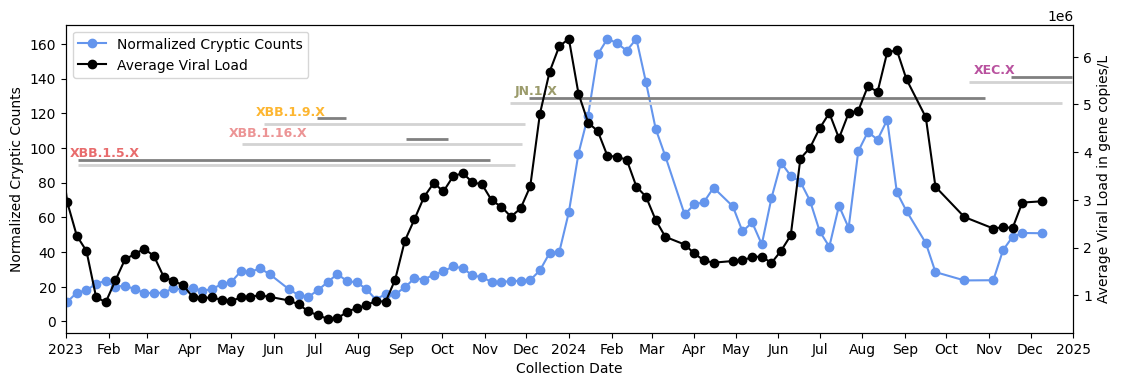

In [118]:
# B: Plot both cryptic counts and viral load over time with dual y-axes
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

# Plot main data
ax1.plot(
    df['week'], 
    df['cryptic_counts_normalized'], 
    color='cornflowerblue', marker='o', label='Normalized Cryptic Counts'
)
ax2.plot(
    df['week'], 
    df['avg_viral_load'], 
    color='black', marker='o', label='Average Viral Load'
)

ax1.set_xlabel('Collection Date')
ax1.set_ylabel('Normalized Cryptic Counts')
ax2.set_ylabel('Average Viral Load in gene copies/L')

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh1.values():
    # Draw horizontal line
    ax1.hlines(y, start, end, colors='lightgray', linewidth=2)

    ax1.text(
        start + pd.Timedelta(19, 'D'), y + 3,  # slight vertical offset
        label,
        ha='center', va='bottom',
        fontsize=9, color=colors_dict.get(label),
        rotation=0, fontweight='bold'
    )

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh2.values():
    # Draw horizontal line
    ax1.hlines(y + 3, start, end, colors='gray', linewidth=2)


# --- Combine legends for line plots only ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# --- Format x-axis ---
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(plt.FuncFormatter(custom_month_year_formatter))

# --- Fit limits ---
ax1.set_xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'))

plt.savefig(
    'plots/cryptics_viral_load_linechart.pdf',
    transparent=True,
    bbox_inches='tight',
    dpi=300
)

In [119]:
# Convert week periods to timestamps

WEEKS_SPAN = 16
PREVALENCE_THRESH1 = 0.05
PREVALENCE_THRESH2 = 0.95


def calculate_cryptic_percentage(start_date, weeks_offset=WEEKS_SPAN):
    """Calculate percentage of cryptic lineages detected in time window around time window"""
    end_date = start_date + pd.Timedelta(weeks=weeks_offset)
    
    window_cryptics = df[
        (df['week'] >= start_date) & 
        (df['week'] <= end_date)
    ]['cryptic_counts_normalized'].sum()
    
    total_cryptics = df['cryptic_counts_normalized'].sum()
    return window_cryptics / total_cryptics * 100

first_detection_dates = {}
for lineage in LINEAGES:
    first_detection_dates[lineage] = lineage_prevalence[lineage_prevalence[lineage] > PREVALENCE_THRESH1]['Date'].min()

first_ninety_percent_prevalence_dates = {}
for lineage in LINEAGES:
    first_ninety_percent_prevalence_dates[lineage] = lineage_prevalence[lineage_prevalence[lineage] > PREVALENCE_THRESH2]['Date'].min()

print(f"First {PREVALENCE_THRESH1*100}% prevalence dates:")
for lineage in LINEAGES:
    print(f"{lineage}: {first_detection_dates[lineage]}")

print(f"\nFirst {PREVALENCE_THRESH2*100}% prevalence dates:")
for lineage in LINEAGES:
    print(f"{lineage}: {first_ninety_percent_prevalence_dates[lineage]}")

# Print the number of weeks between first detection and first 95% prevalence
for lineage in LINEAGES:
    print(f"{lineage}: {first_ninety_percent_prevalence_dates[lineage] - first_detection_dates[lineage]}")

print(f"\nPercent normalized cryptic lineages within {WEEKS_SPAN} weeks after {PREVALENCE_THRESH1*100}% prevalence:")
for lineage in LINEAGES:
    percentage = calculate_cryptic_percentage(first_detection_dates[lineage])
    print(f"% {lineage}: {percentage:.2f}")

First 5.0% prevalence dates:
XBB.1.5.X: 2023-01-10 00:00:00
XBB.1.16.X: 2023-05-09 00:00:00
XBB.1.9.X: 2023-05-25 00:00:00
JN.1.X: 2023-11-19 00:00:00
XEC.X: 2024-10-17 00:00:00

First 95.0% prevalence dates:
XBB.1.5.X: NaT
XBB.1.16.X: NaT
XBB.1.9.X: NaT
JN.1.X: 2024-02-04 00:00:00
XEC.X: NaT
XBB.1.5.X: NaT
XBB.1.16.X: NaT
XBB.1.9.X: NaT
JN.1.X: 77 days 00:00:00
XEC.X: NaT

Percent normalized cryptic lineages within 16 weeks after 5.0% prevalence:
% XBB.1.5.X: 6.78
% XBB.1.16.X: 6.82
% XBB.1.9.X: 6.50
% JN.1.X: 33.08
% XEC.X: 4.74
